# 07 — Model Evaluation & Selection

**Goal:** Compare all trained models across both datasets, select the best one per dataset, analyze feature importance, and save final production models as `.pkl` files.

| Step | What | Why |
|------|------|-----|
| 1 | Load all models + summaries | Compare on a level playing field |
| 2 | Cross-dataset comparison | One table to rule them all |
| 3 | ROC curves | Visual AUC comparison — especially important under class imbalance |
| 4 | Confusion matrix heatmaps | See which classes get confused |
| 5 | Feature importance (symptoms) | Which symptoms drive risk level? |
| 6 | Feature importance (clinical) | Which lab values are most diagnostic? |
| 7 | Select & save best models | Final `.pkl` files for FastAPI |

In [1]:
import pandas as pd
import numpy as np
import joblib
import os
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
sns.set_theme(style="whitegrid", palette="muted")

from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    roc_curve, auc,
    confusion_matrix, ConfusionMatrixDisplay,
    RocCurveDisplay
)

os.makedirs("../models", exist_ok=True)
print("Libraries loaded ✓")

Libraries loaded ✓


## 1. Load Data & Models

In [3]:
# ── Symptoms data ──────────────────────────────────────────
Xs_train = pd.read_csv("../data/processed/symptoms_X_train.csv")
ys_train = pd.read_csv("../data/processed/symptoms_y_train.csv").squeeze()
Xs_test  = pd.read_csv("../data/processed/symptoms_X_test.csv")
ys_test  = pd.read_csv("../data/processed/symptoms_y_test.csv").squeeze()
risk_meta = joblib.load("../models/symptoms/risk_meta.pkl")

# ── Clinical data ──────────────────────────────────────────
Xc_train = pd.read_csv("../data/processed/clinical_X_train.csv")
yc_train = pd.read_csv("../data/processed/clinical_y_train.csv").squeeze()
Xc_test  = pd.read_csv("../data/processed/clinical_X_test.csv")
yc_test  = pd.read_csv("../data/processed/clinical_y_test.csv").squeeze()

# ── Reconstruct risk levels for symptoms test set ──────────
HIGH_SIGNAL_COLS = risk_meta["high_signal_cols"]

def assign_risk(X, y_binary):
    y_binary = np.array(y_binary)
    burden = X[HIGH_SIGNAL_COLS].gt(0).sum(axis=1).values
    pcos_mask = y_binary == 1
    median_burden = np.median(burden[pcos_mask]) if pcos_mask.sum() > 0 else np.median(burden)
    return np.where(y_binary == 0, 0, np.where(burden >= median_burden, 2, 1))

ys_test_risk  = assign_risk(Xs_test,  ys_test)
ys_train_risk = assign_risk(Xs_train, ys_train)

MODEL_NAMES = ["logistic_regression", "random_forest", "xgboost"]
DISPLAY_NAMES = ["Logistic Regression", "Random Forest", "XGBoost"]

# Load all models
sym_models  = {n: joblib.load(f"../models/symptoms/{n}.pkl") for n in MODEL_NAMES}
clin_models = {n: joblib.load(f"../models/clinical/{n}.pkl") for n in MODEL_NAMES}

print("All models loaded ✓")
print(f"  Symptoms test : {Xs_test.shape[0]} rows — classes {np.unique(ys_test_risk)}")
print(f"  Clinical test : {Xc_test.shape[0]} rows — classes {np.unique(yc_test)}")

All models loaded ✓
  Symptoms test : 137 rows — classes [0 1 2]
  Clinical test : 94 rows — classes [0 1]


## 2. Load Training Summaries

In [4]:
sym_summary  = pd.read_csv("../models/symptoms/training_summary.csv")
clin_summary = pd.read_csv("../models/clinical/training_summary.csv")

print("=== SYMPTOMS — Risk Level Prediction (Low / Medium / High) ===")
print(sym_summary.to_string(index=False))

print("\n=== CLINICAL — PCOS / No PCOS ===")
print(clin_summary.to_string(index=False))

=== SYMPTOMS — Risk Level Prediction (Low / Medium / High) ===
              Model  Accuracy  F1 Macro  F1 Weighted  ROC-AUC
      Random Forest    0.8540    0.8325       0.8581   0.9750
            XGBoost    0.8394    0.8137       0.8435   0.9654
Logistic Regression    0.8248    0.7939       0.8288   0.9514

=== CLINICAL — PCOS / No PCOS ===
              Model  Accuracy  F1 (PCOS)  F1 Macro  ROC-AUC
      Random Forest    0.5532     0.3824    0.5162   0.5444
            XGBoost    0.5426     0.4819    0.5362   0.4913
Logistic Regression    0.4255     0.4130    0.4253   0.3864


## 3. ROC Curves

### 3a. Symptoms — Multi-class OVR ROC

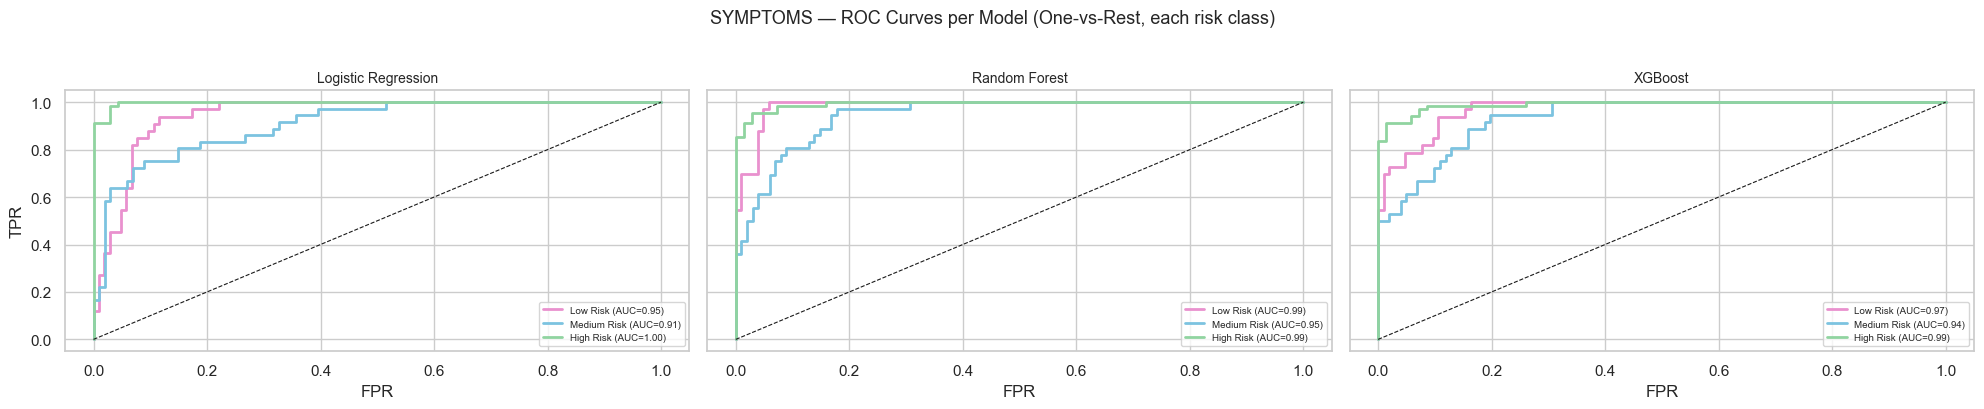

Saved: ../models/symptoms/roc_curves.png


In [5]:
label_names_sym  = risk_meta["label_names"]   # [Low, Medium, High]
label_names_clin = ["No PCOS", "PCOS"]

ys_bin = label_binarize(ys_test_risk, classes=[0, 1, 2])

fig, axes = plt.subplots(1, len(MODEL_NAMES), figsize=(20, 4), sharey=True)
fig.suptitle("SYMPTOMS — ROC Curves per Model (One-vs-Rest, each risk class)", fontsize=13, y=1.02)

colors = ["#E991CE", "#7CC3E0", "#90D4A0"]

for ax, (fname, dname) in zip(axes, zip(MODEL_NAMES, DISPLAY_NAMES)):
    model = sym_models[fname]
    proba = model.predict_proba(Xs_test)
    for cls_idx, (cls_name, color) in enumerate(zip(label_names_sym, colors)):
        fpr, tpr, _ = roc_curve(ys_bin[:, cls_idx], proba[:, cls_idx])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=color, lw=2, label=f"{cls_name} (AUC={roc_auc:.2f})")
    ax.plot([0,1],[0,1], "k--", lw=0.8)
    ax.set_title(dname, fontsize=10)
    ax.set_xlabel("FPR")
    ax.legend(fontsize=7, loc="lower right")

axes[0].set_ylabel("TPR")
plt.tight_layout()
plt.savefig("../models/symptoms/roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: ../models/symptoms/roc_curves.png")

### 3b. Clinical — Binary ROC

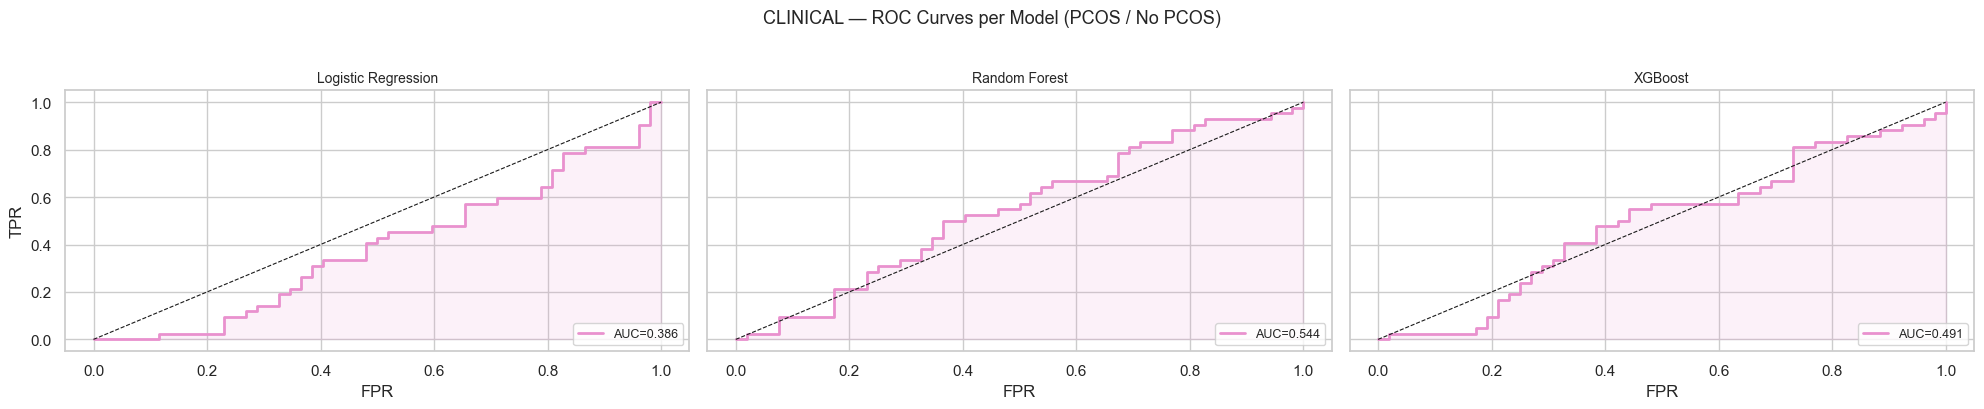

Saved: ../models/clinical/roc_curves.png


In [6]:
fig, axes = plt.subplots(1, len(MODEL_NAMES), figsize=(20, 4), sharey=True)
fig.suptitle("CLINICAL — ROC Curves per Model (PCOS / No PCOS)", fontsize=13, y=1.02)

for ax, (fname, dname) in zip(axes, zip(MODEL_NAMES, DISPLAY_NAMES)):
    model = clin_models[fname]
    proba = model.predict_proba(Xc_test)[:, 1]
    fpr, tpr, _ = roc_curve(yc_test, proba)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color="#E991CE", lw=2, label=f"AUC={roc_auc:.3f}")
    ax.fill_between(fpr, tpr, alpha=0.12, color="#E991CE")
    ax.plot([0,1],[0,1], "k--", lw=0.8)
    ax.set_title(dname, fontsize=10)
    ax.set_xlabel("FPR")
    ax.legend(fontsize=9, loc="lower right")

axes[0].set_ylabel("TPR")
plt.tight_layout()
plt.savefig("../models/clinical/roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: ../models/clinical/roc_curves.png")

## 4. Confusion Matrix Heatmaps

### 4a. Symptoms — Best Model

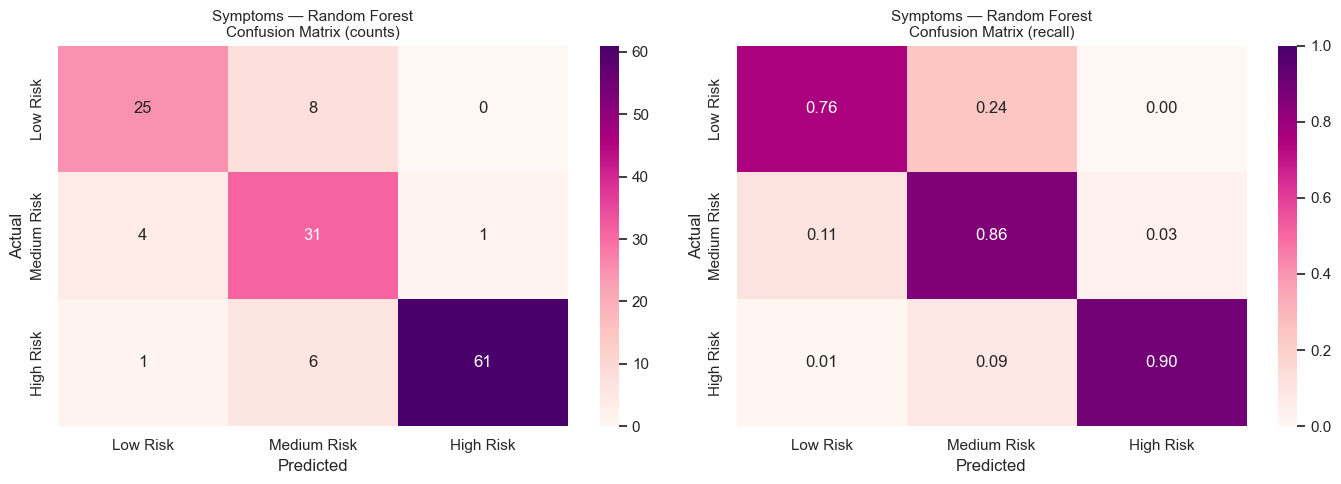

In [7]:
best_sym_name = sym_summary.sort_values("ROC-AUC", ascending=False).iloc[0]["Model"]
best_sym_fname = best_sym_name.lower().replace(" ", "_")
best_sym_model = sym_models[best_sym_fname]

ys_pred = best_sym_model.predict(Xs_test)
cm_sym  = confusion_matrix(ys_test_risk, ys_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
sns.heatmap(cm_sym, annot=True, fmt="d", cmap="RdPu",
            xticklabels=label_names_sym, yticklabels=label_names_sym, ax=axes[0])
axes[0].set_title(f"Symptoms — {best_sym_name}\nConfusion Matrix (counts)", fontsize=11)
axes[0].set_ylabel("Actual")
axes[0].set_xlabel("Predicted")

# Normalized (recall per class)
cm_norm = cm_sym.astype(float) / cm_sym.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="RdPu",
            xticklabels=label_names_sym, yticklabels=label_names_sym,
            vmin=0, vmax=1, ax=axes[1])
axes[1].set_title(f"Symptoms — {best_sym_name}\nConfusion Matrix (recall)", fontsize=11)
axes[1].set_ylabel("Actual")
axes[1].set_xlabel("Predicted")

plt.tight_layout()
plt.savefig("../models/symptoms/confusion_matrix_best.png", dpi=150, bbox_inches="tight")
plt.show()

### 4b. Clinical — Best Model

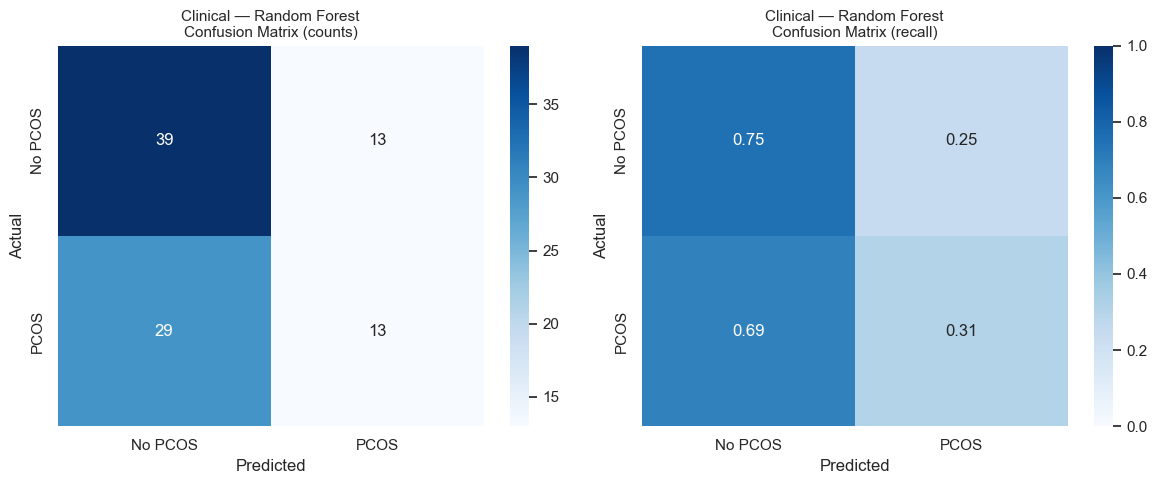

In [8]:
best_clin_name  = clin_summary.sort_values("ROC-AUC", ascending=False).iloc[0]["Model"]
best_clin_fname = best_clin_name.lower().replace(" ", "_")
best_clin_model = clin_models[best_clin_fname]

yc_pred = best_clin_model.predict(Xc_test)
cm_clin = confusion_matrix(yc_test, yc_pred)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm_clin, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_names_clin, yticklabels=label_names_clin, ax=axes[0])
axes[0].set_title(f"Clinical — {best_clin_name}\nConfusion Matrix (counts)", fontsize=11)
axes[0].set_ylabel("Actual")
axes[0].set_xlabel("Predicted")

cm_norm_c = cm_clin.astype(float) / cm_clin.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm_c, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=label_names_clin, yticklabels=label_names_clin,
            vmin=0, vmax=1, ax=axes[1])
axes[1].set_title(f"Clinical — {best_clin_name}\nConfusion Matrix (recall)", fontsize=11)
axes[1].set_ylabel("Actual")
axes[1].set_xlabel("Predicted")

plt.tight_layout()
plt.savefig("../models/clinical/confusion_matrix_best.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Feature Importance — Symptoms Dataset

We use two complementary methods:
- **Tree-based importance** (Random Forest / XGBoost): mean impurity decrease
- **Logistic Regression coefficients**: direct weight → direction of influence

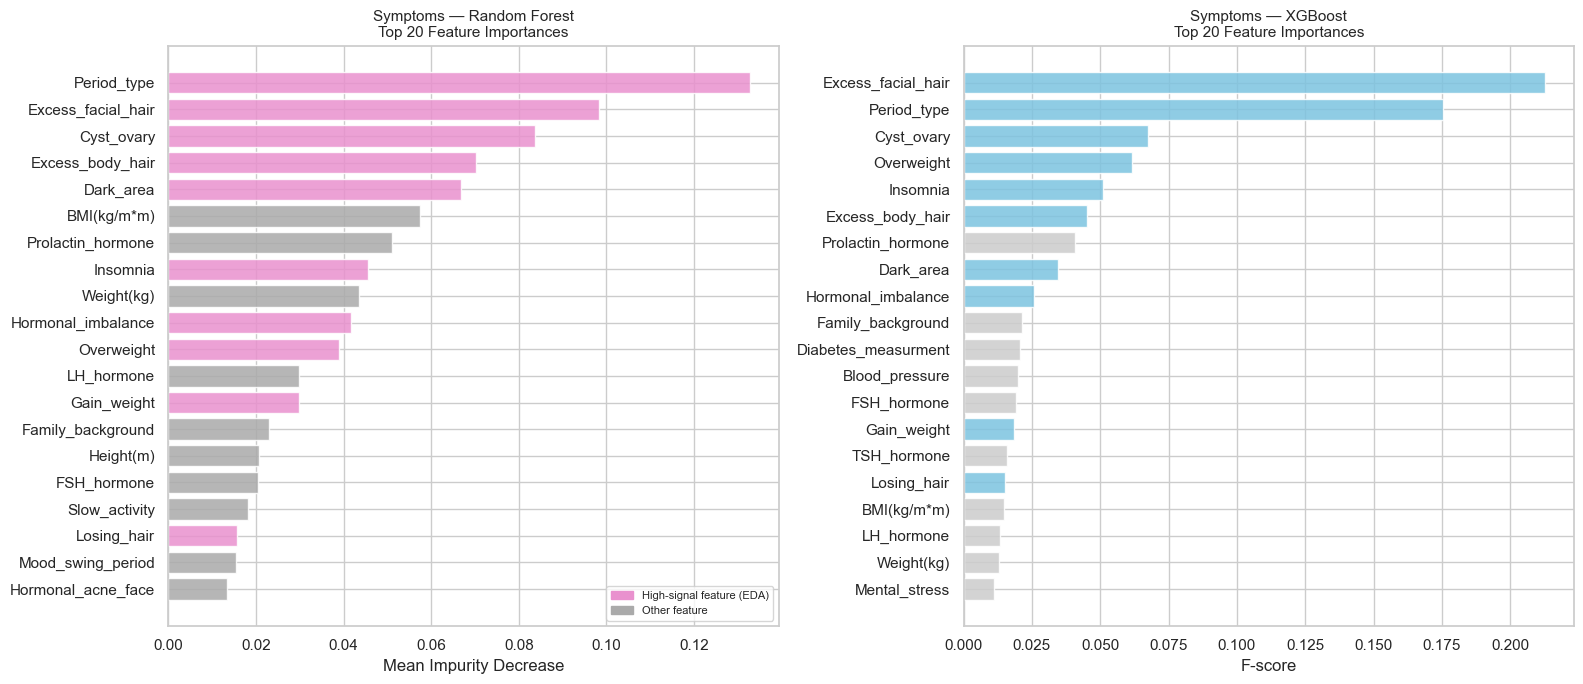


Top 10 symptoms driving PCOS risk (Random Forest):
   1. Period_type                         0.1327
   2. Excess_facial_hair                  0.0982
   3. Cyst_ovary                          0.0837
   4. Excess_body_hair                    0.0702
   5. Dark_area                           0.0667
   6. BMI(kg/m*m)                         0.0573
   7. Prolactin_hormone                   0.0510
   8. Insomnia                            0.0456
   9. Weight(kg)                          0.0436
  10. Hormonal_imbalance                  0.0417


In [9]:
feature_cols_sym = list(Xs_test.columns)

# ── Random Forest importance ───────────────────────────────
rf_sym = sym_models["random_forest"]
rf_imp = pd.Series(rf_sym.feature_importances_, index=feature_cols_sym)
rf_imp = rf_imp.sort_values(ascending=False)

# ── XGBoost importance ─────────────────────────────────────
xgb_sym = sym_models["xgboost"]
xgb_imp = pd.Series(xgb_sym.feature_importances_, index=feature_cols_sym)
xgb_imp = xgb_imp.sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# RF
top_n = 20
colors_rf = ["#E991CE" if f in HIGH_SIGNAL_COLS else "#AAAAAA" for f in rf_imp.index[:top_n]]
axes[0].barh(rf_imp.index[:top_n][::-1], rf_imp.values[:top_n][::-1],
             color=colors_rf[::-1], alpha=0.85)
axes[0].set_title("Symptoms — Random Forest\nTop 20 Feature Importances", fontsize=11)
axes[0].set_xlabel("Mean Impurity Decrease")
# Legend patch
from matplotlib.patches import Patch
axes[0].legend(handles=[
    Patch(color="#E991CE", label="High-signal feature (EDA)"),
    Patch(color="#AAAAAA", label="Other feature")
], fontsize=8, loc="lower right")

# XGBoost
colors_xgb = ["#7CC3E0" if f in HIGH_SIGNAL_COLS else "#CCCCCC" for f in xgb_imp.index[:top_n]]
axes[1].barh(xgb_imp.index[:top_n][::-1], xgb_imp.values[:top_n][::-1],
             color=colors_xgb[::-1], alpha=0.85)
axes[1].set_title("Symptoms — XGBoost\nTop 20 Feature Importances", fontsize=11)
axes[1].set_xlabel("F-score")

plt.tight_layout()
plt.savefig("../models/symptoms/feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nTop 10 symptoms driving PCOS risk (Random Forest):")
for i, (feat, val) in enumerate(rf_imp.head(10).items(), 1):
    print(f"  {i:2d}. {feat:<35} {val:.4f}")

## 6. Feature Importance — Clinical Dataset

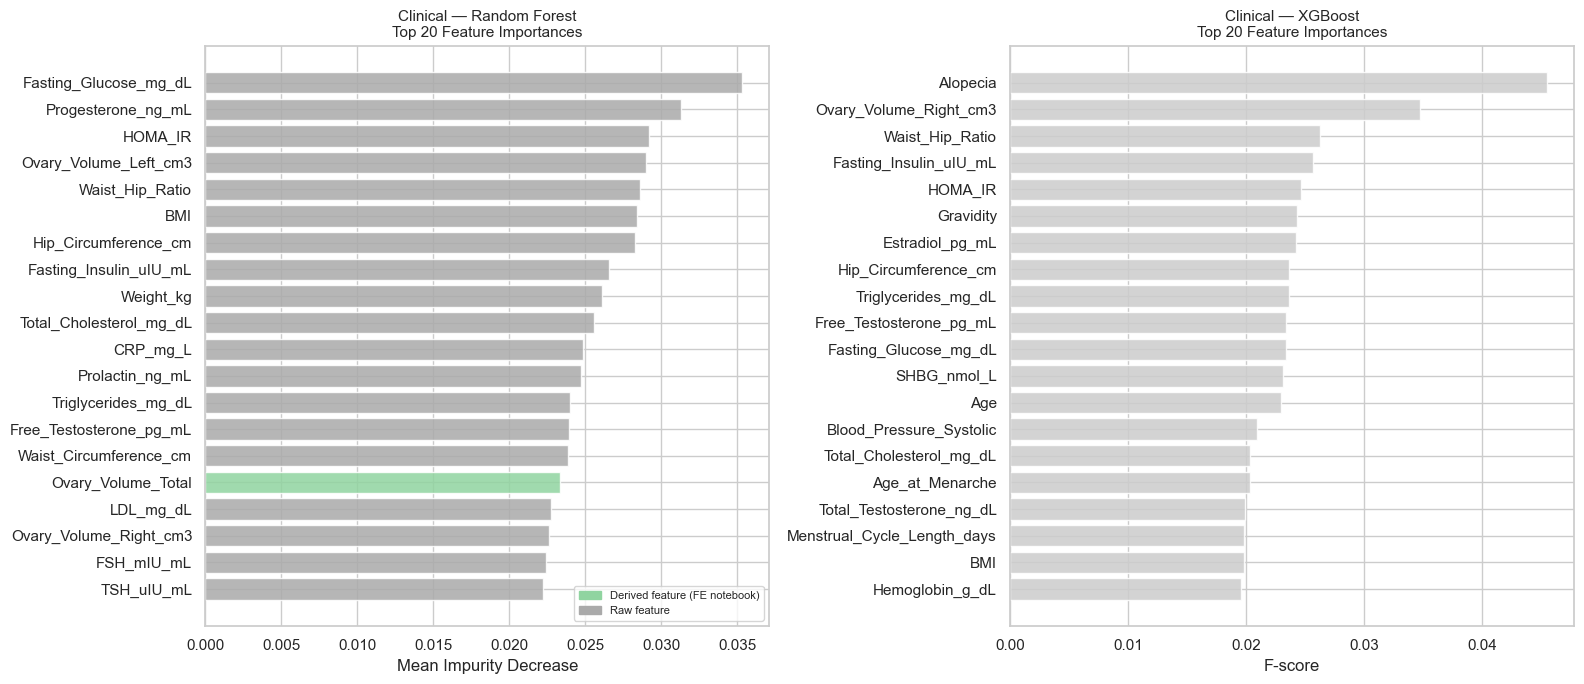


Top 10 clinical features driving PCOS diagnosis (Random Forest):
   1. Fasting_Glucose_mg_dL                    0.0353
   2. Progesterone_ng_mL                       0.0313
   3. HOMA_IR                                  0.0292
   4. Ovary_Volume_Left_cm3                    0.0290
   5. Waist_Hip_Ratio                          0.0286
   6. BMI                                      0.0284
   7. Hip_Circumference_cm                     0.0283
   8. Fasting_Insulin_uIU_mL                   0.0265
   9. Weight_kg                                0.0261
  10. Total_Cholesterol_mg_dL                  0.0256


In [10]:
feature_cols_clin = list(Xc_test.columns)

rf_clin  = clin_models["random_forest"]
xgb_clin = clin_models["xgboost"]

rf_imp_c  = pd.Series(rf_clin.feature_importances_,  index=feature_cols_clin).sort_values(ascending=False)
xgb_imp_c = pd.Series(xgb_clin.feature_importances_, index=feature_cols_clin).sort_values(ascending=False)

# Mark derived features
DERIVED_COLS = ["FAI", "Follicle_Count_Total", "Ovary_Volume_Total"]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

top_n = 20
colors_rf_c  = ["#90D4A0" if f in DERIVED_COLS else "#AAAAAA" for f in rf_imp_c.index[:top_n]]
colors_xgb_c = ["#90D4A0" if f in DERIVED_COLS else "#CCCCCC" for f in xgb_imp_c.index[:top_n]]

axes[0].barh(rf_imp_c.index[:top_n][::-1],  rf_imp_c.values[:top_n][::-1],
             color=colors_rf_c[::-1], alpha=0.85)
axes[0].set_title("Clinical — Random Forest\nTop 20 Feature Importances", fontsize=11)
axes[0].set_xlabel("Mean Impurity Decrease")
axes[0].legend(handles=[
    Patch(color="#90D4A0", label="Derived feature (FE notebook)"),
    Patch(color="#AAAAAA", label="Raw feature")
], fontsize=8, loc="lower right")

axes[1].barh(xgb_imp_c.index[:top_n][::-1], xgb_imp_c.values[:top_n][::-1],
             color=colors_xgb_c[::-1], alpha=0.85)
axes[1].set_title("Clinical — XGBoost\nTop 20 Feature Importances", fontsize=11)
axes[1].set_xlabel("F-score")

plt.tight_layout()
plt.savefig("../models/clinical/feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nTop 10 clinical features driving PCOS diagnosis (Random Forest):")
for i, (feat, val) in enumerate(rf_imp_c.head(10).items(), 1):
    tag = " ← derived" if feat in DERIVED_COLS else ""
    print(f"  {i:2d}. {feat:<40} {val:.4f}{tag}")

## 7. Head-to-Head Comparison — All Models, Both Datasets

In [12]:
sym_summary["Dataset"]  = "Symptoms (Risk Level)"
clin_summary["Dataset"] = "Clinical (PCOS/No PCOS)"

# Rename clinical columns to match
clin_summary_display = clin_summary.rename(columns={"F1 (PCOS)": "F1 Macro"})

all_results = pd.concat([sym_summary, clin_summary_display], ignore_index=True)

print("=" * 75)
print("FULL COMPARISON — All Models, Both Datasets")
print("=" * 75)
print(all_results[["Dataset","Model","Accuracy","F1 Macro","ROC-AUC"]].to_string(index=False))

# Visual comparison
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
metrics = ["Accuracy", "F1 Macro", "ROC-AUC"]
palette = {"Symptoms (Risk Level)": "#E991CE", "Clinical (PCOS/No PCOS)": "#7CC3E0"}

for ax, metric in zip(axes, metrics):
    sns.barplot(
        data=all_results, x="Model", y=metric, hue="Dataset",
        palette=palette, ax=ax, alpha=0.85
    )
    ax.set_title(metric, fontsize=12)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right", fontsize=8)
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=7)
    ax.axhline(0.8, color="gray", lw=0.8, linestyle="--", label="0.8 threshold")

plt.suptitle("Model Comparison — Symptoms vs Clinical", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("../models/comparison_all_models.png", dpi=150, bbox_inches="tight")
plt.show()

InvalidIndexError: Reindexing only valid with uniquely valued Index objects

## 8. Select Best Models & Save as Final .pkl

In [13]:
# ── Selection criteria ─────────────────────────────────────
# Primary: ROC-AUC (most robust under class imbalance)
# Tiebreak: F1 Macro

best_sym_row  = sym_summary.sort_values(["ROC-AUC", "F1 Macro"], ascending=False).iloc[0]
best_clin_row = clin_summary.sort_values(["ROC-AUC", "F1 Macro"], ascending=False).iloc[0]

best_sym_fname  = best_sym_row["Model"].lower().replace(" ", "_")
best_clin_fname = best_clin_row["Model"].lower().replace(" ", "_")

best_sym_model  = sym_models[best_sym_fname]
best_clin_model = clin_models[best_clin_fname]

print("══ SELECTED MODELS ══")
print(f"  Symptoms → {best_sym_row['Model']}")
print(f"    Accuracy={best_sym_row['Accuracy']}  F1 Macro={best_sym_row['F1 Macro']}  ROC-AUC={best_sym_row['ROC-AUC']}")
print()
print(f"  Clinical → {best_clin_row['Model']}")
print(f"    Accuracy={best_clin_row['Accuracy']}  F1 Macro={best_clin_row['F1 Macro']}  ROC-AUC={best_clin_row['ROC-AUC']}")

# ── Save final production models ───────────────────────────
joblib.dump(best_sym_model,  "../models/best_symptoms_model.pkl")
joblib.dump(best_clin_model, "../models/best_clinical_model.pkl")

# Save selection metadata (for FastAPI model loader)
selection_meta = {
    "symptoms": {
        "model_name":  best_sym_row["Model"],
        "task":        "risk_level_multiclass",
        "classes":     risk_meta["label_names"],
        "n_classes":   3,
        "metric_used": "ROC-AUC (OVR macro)",
        "roc_auc":     float(best_sym_row["ROC-AUC"]),
        "f1_macro":    float(best_sym_row["F1 Macro"]),
        "accuracy":    float(best_sym_row["Accuracy"]),
    },
    "clinical": {
        "model_name":  best_clin_row["Model"],
        "task":        "binary_pcos_diagnosis",
        "classes":     ["No PCOS", "PCOS"],
        "n_classes":   2,
        "metric_used": "ROC-AUC",
        "roc_auc":     float(best_clin_row["ROC-AUC"]),
        "f1_macro":    float(best_clin_row["F1 Macro"]),
        "accuracy":    float(best_clin_row["Accuracy"]),
    }
}
joblib.dump(selection_meta, "../models/selection_meta.pkl")

print("\nSaved:")
print("  ../models/best_symptoms_model.pkl")
print("  ../models/best_clinical_model.pkl")
print("  ../models/selection_meta.pkl")

══ SELECTED MODELS ══
  Symptoms → Random Forest
    Accuracy=0.854  F1 Macro=0.8325  ROC-AUC=0.975

  Clinical → Random Forest
    Accuracy=0.5532  F1 Macro=0.5162  ROC-AUC=0.5444

Saved:
  ../models/best_symptoms_model.pkl
  ../models/best_clinical_model.pkl
  ../models/selection_meta.pkl


## 9. Final Summary

In [14]:
print("""╔══════════════════════════════════════════════════════════════╗
║              STEP 4 — MODEL EVALUATION COMPLETE              ║
╠══════════════════════════════════════════════════════════════╣
║  SYMPTOMS DATASET                                            ║
║  Task   : Risk Level — Low / Medium / High (3-class)         ║""")
print(f"║  Winner : {best_sym_row['Model']:<50} ║")
print(f"║  ROC-AUC: {best_sym_row['ROC-AUC']:<50} ║")
print(f"║  F1 Mac : {best_sym_row['F1 Macro']:<50} ║")
print("""╠══════════════════════════════════════════════════════════════╣
║  CLINICAL DATASET                                            ║
║  Task   : PCOS / No PCOS (binary)                            ║""")
print(f"║  Winner : {best_clin_row['Model']:<50} ║")
print(f"║  ROC-AUC: {best_clin_row['ROC-AUC']:<50} ║")
print(f"║  F1 Mac : {best_clin_row['F1 Macro']:<50} ║")
print("""╠══════════════════════════════════════════════════════════════╣
║  SAVED ARTIFACTS                                             ║
║  best_symptoms_model.pkl  → FastAPI symptoms endpoint        ║
║  best_clinical_model.pkl  → FastAPI clinical endpoint        ║
║  selection_meta.pkl       → model metadata for API           ║
╚══════════════════════════════════════════════════════════════╝""")

╔══════════════════════════════════════════════════════════════╗
║              STEP 4 — MODEL EVALUATION COMPLETE              ║
╠══════════════════════════════════════════════════════════════╣
║  SYMPTOMS DATASET                                            ║
║  Task   : Risk Level — Low / Medium / High (3-class)         ║
║  Winner : Random Forest                                      ║
║  ROC-AUC: 0.975                                              ║
║  F1 Mac : 0.8325                                             ║
╠══════════════════════════════════════════════════════════════╣
║  CLINICAL DATASET                                            ║
║  Task   : PCOS / No PCOS (binary)                            ║
║  Winner : Random Forest                                      ║
║  ROC-AUC: 0.5444                                             ║
║  F1 Mac : 0.5162                                             ║
╠══════════════════════════════════════════════════════════════╣
║  SAVED ARTIFACTS       